In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
from utils.utils import lat_lon_to_grid_index

import os
os.chdir("/home/tsternal/phd/WeatherExtremes2")  # adjust

zarr = "vienna_weatherbench2_2m_temperature_daily_mean.zarr"
data = xr.open_zarr(f'data/preprocessed/{zarr}')['2m_temperature']
print(data)

# vienna_lat, vienna_lon = 48.210033, 16.363449
# array_2d = data['2m_temperature'].sel(time="2020-01-01").squeeze().values  # remove single-dimensional entries, if any
# vienna_x, vienna_y = lat_lon_to_grid_index(vienna_lat, vienna_lon, data)
# data_vienna = xr.open_zarr('data/preprocessed/2_weatherbench2_2m_temperature_daily_mean_vienna_2020-2021.zarr')['2m_temperature'].isel(latitude=vienna_x, longitude=vienna_y)

<xarray.DataArray '2m_temperature' (time: 22995)> Size: 92kB
dask.array<open_dataset-2m_temperature, shape=(22995,), dtype=float32, chunksize=(365,), chunktype=numpy.ndarray>
Coordinates:
    latitude   float32 4B ...
    longitude  float32 4B ...
  * time       (time) object 184kB 1959-01-01 00:00:00 ... 2021-12-31 00:00:00
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K


In [9]:
import numpy as np
data = data.values.reshape(63,365) - 273.15  # Convert from Kelvin to Celsius

# data = np.stack(([data[0]] * 59) + [data[1]] , axis=0)
data = np.stack(([data[-1]] * 60), axis=0)
mean_values = np.linspace(1, 0, 60)  # shape (60,)
gaussian_samples = np.random.normal(loc=mean_values[:, None], scale=1, size=(60, 365))

mean_values_smaller = np.linspace(1, 0, 60)  # shape (60,)
gaussian_samples_smaller = np.random.normal(loc=mean_values_smaller[:, None], scale=1, size=(60, 365))

trend_up = data - gaussian_samples
trend_down = data + gaussian_samples


trend_up_smaller = trend_up = data - gaussian_samples_smaller


In [10]:
def plot_exceedances(exceedances):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(15, 6))
    plt.imshow(exceedances, aspect='auto', cmap='Reds', interpolation='none', vmin=0, vmax=1)
    plt.xlabel('Day of Year')
    plt.ylabel('Year')
    plt.title('Exceedances (1 = exceedance, 0 = no exceedance)')
    plt.colorbar(label='Exceedance')
    plt.show()
    
def get_exceedances(data, percentiles, perc_id=0):
    exceedances = np.zeros((60, 365))
    for year in range(60):
        for doy in range(365):
            exceedances[year][doy] = data[year][doy] > percentiles[doy][perc_id]
    return exceedances

JUN=5
AUG=7
def count_ex_per_period(exceedances, start=JUN, end=AUG):
    # TODO: approximate - use actual dates instead
    start = start *30
    end = (end+1) * 30
    return exceedances[:,start:end+1].sum(axis=1)

def plot_count(data_label_list, title):
    """
    Plots one or more count series, each with its label.

    Args:
        data_label_list: List of (data, label) tuples.
                         Each data is a 1D array-like, label is a string.
    """
    plt.figure(figsize=(15, 6))
    colors = ['b', 'r', 'g', 'm', 'c', 'k']  # Add more as needed
    for i, (count, label) in enumerate(data_label_list):
        color = colors[i % len(colors)]
        plt.plot(count, marker='o', linestyle='-', color=color, label=label)
    plt.title(title)
    plt.xlabel('Year')
    plt.ylabel('Number of Exceedances (JUN-AUG)')
    plt.grid(True)
    if len(data_label_list) > 1:
        plt.legend()
    plt.show()
    
def get_percentile(data, percentile, day_id, year_start=0, year_end=30):
    ref_doy_data = data[year_start:year_end, day_id]
    percentile = np.percentile(ref_doy_data, percentile)
    return percentile

def get_percentile_with_boosting(data, percentile, day_id, year_start=0, year_end=30, boosting=1):
    half = boosting // 2
    start_doy = max(0, day_id - half)
    end_doy = min(364, day_id + half)
    ref_doy_data = data[year_start:year_end, start_doy:end_doy+1].flatten()
    percentile = np.percentile(ref_doy_data, percentile)
    return percentile


def aggregate(data, agg_window):
    """
    Aggregates a 2D array along columns with a centered moving average of window size agg_window.

    Args:
        data (np.ndarray): 2D array. Axis 1 is aggregated.
        agg_window (int): Odd integer for window size.

    Returns:
        np.ndarray: Aggregated data, same shape as input.
    """
    assert agg_window >= 1 and agg_window % 2 == 1, "agg_window must be odd and >= 1"
    rows, cols = data.shape
    half = agg_window // 2
    out = np.empty_like(data)
    for i in range(rows):
        for j in range(cols):
            start = max(0, j - half)
            end = min(cols, j + half + 1)
            out[i, j] = np.mean(data[i, start:end])
    return out

# Simple Experiment 1: 
# synthetic data based on 2020/2021 temp for Vienna, agg_window=1, boosting_window=1, agg=mean, compare trends for 3 percentiles

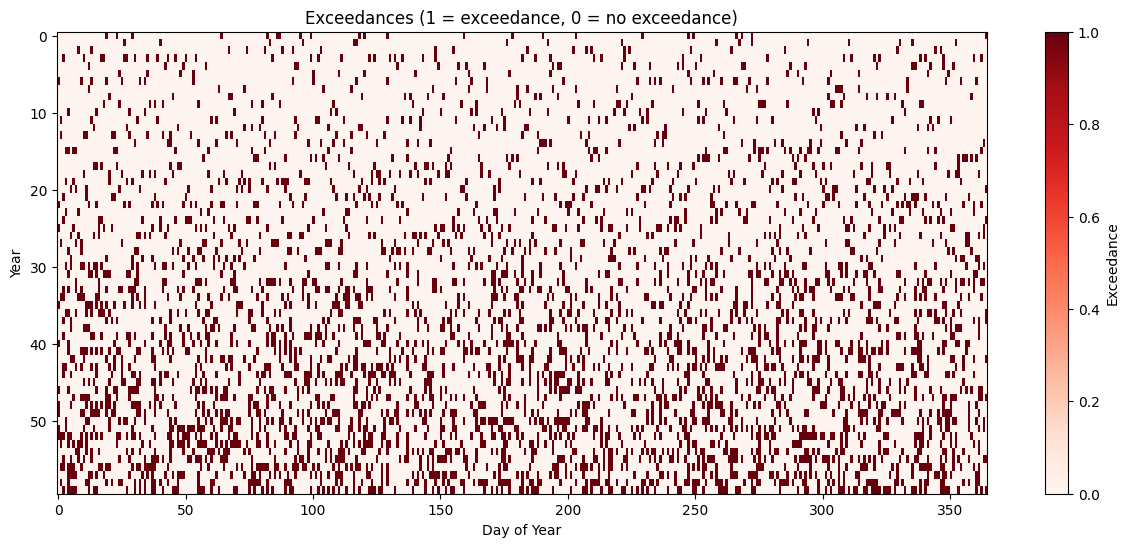

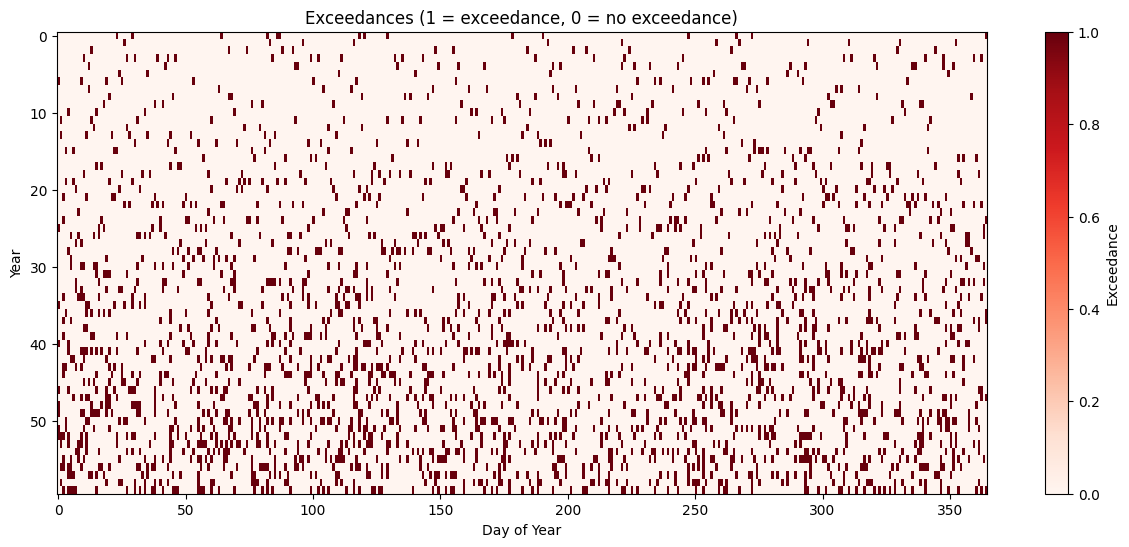

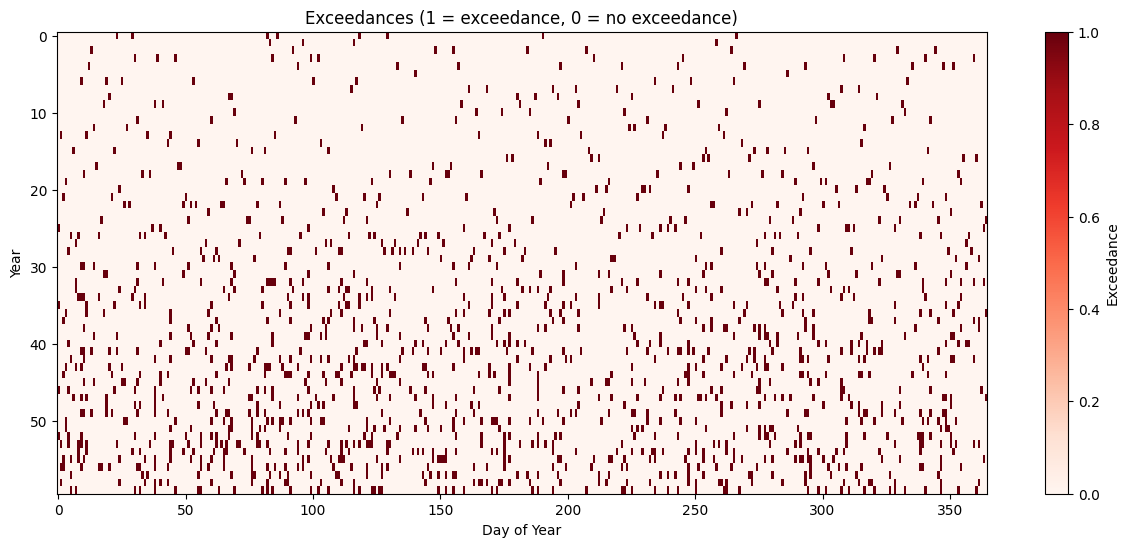

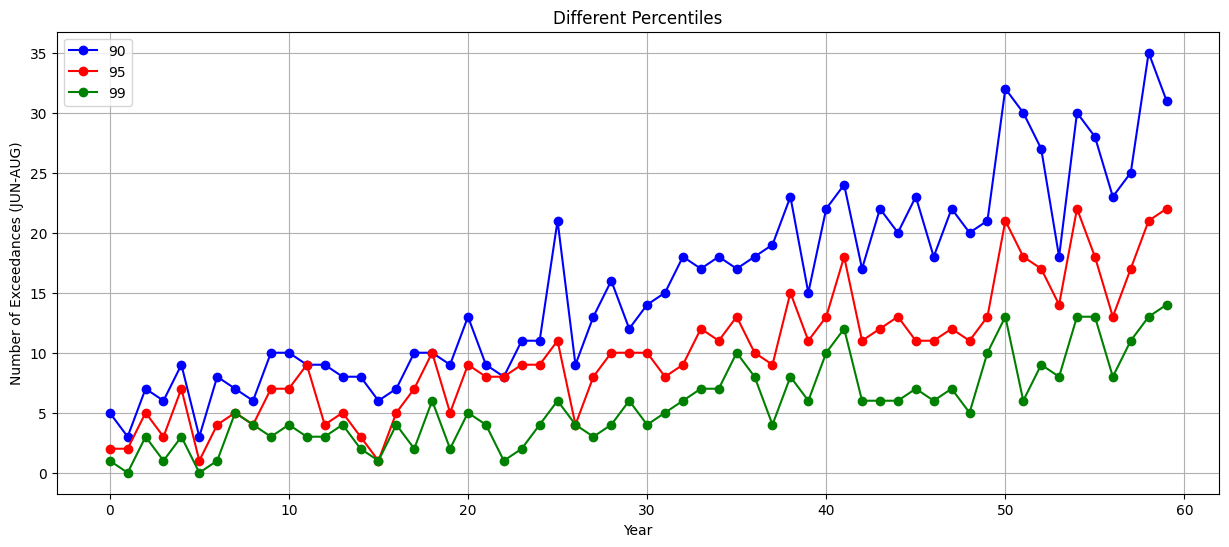

In [11]:
percs = [90, 95, 99]

doy = 30
percentiles = [[get_percentile(trend_up, perc, doy) for perc in percs] for doy in range(365)]

counts = []
for perc_id, perc in enumerate(percs):
    exceedances = get_exceedances(trend_up, percentiles, perc_id)
    plot_exceedances(exceedances)
    summer_exceedances_count = count_ex_per_period(exceedances)
    counts.append( (summer_exceedances_count, perc) )
plot_count(counts, "Different Percentiles")




# Simple Experiment 2: 
# Test different aggregation windows

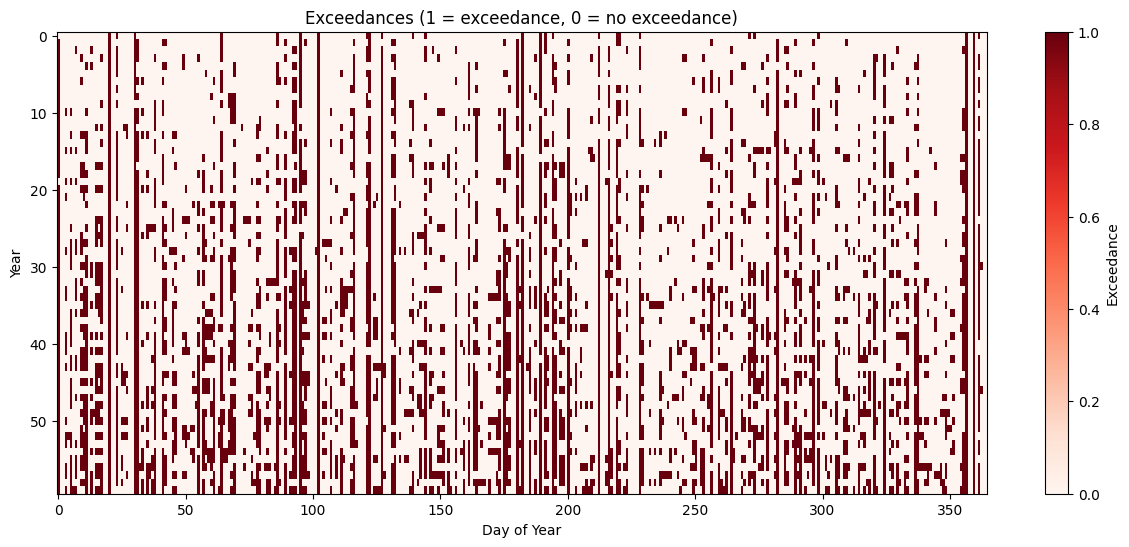

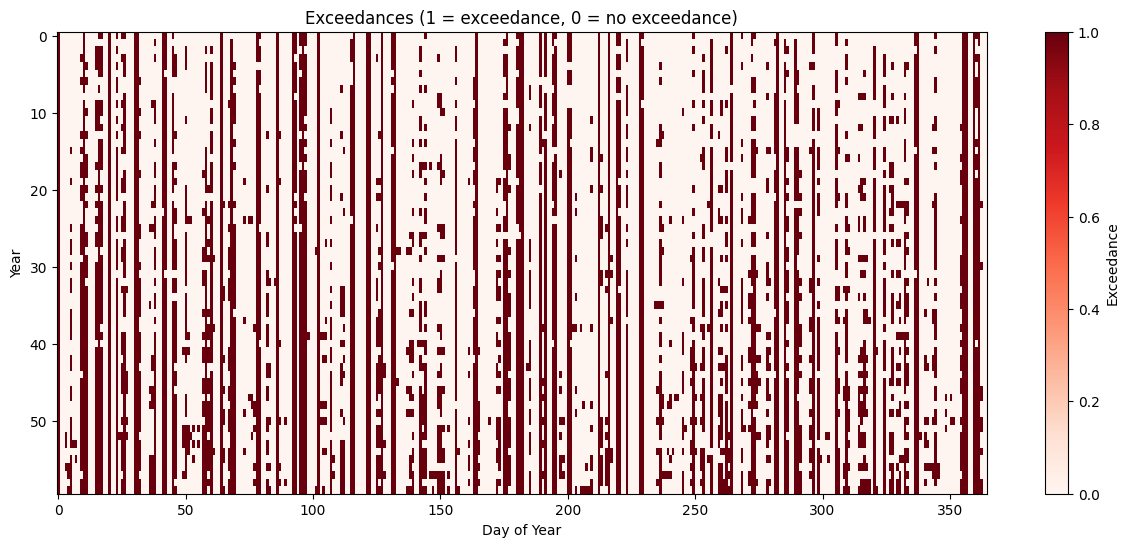

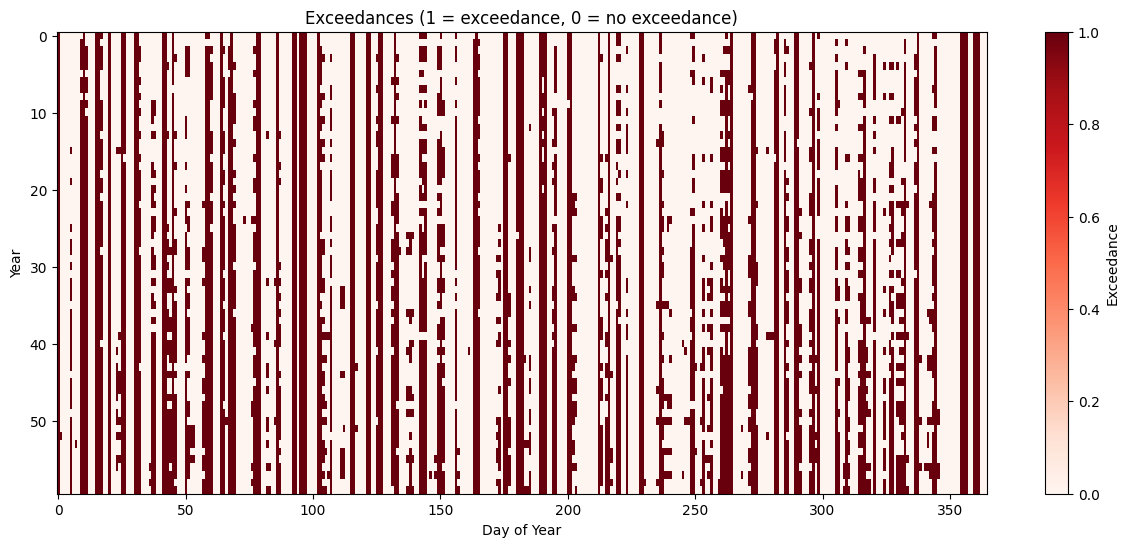

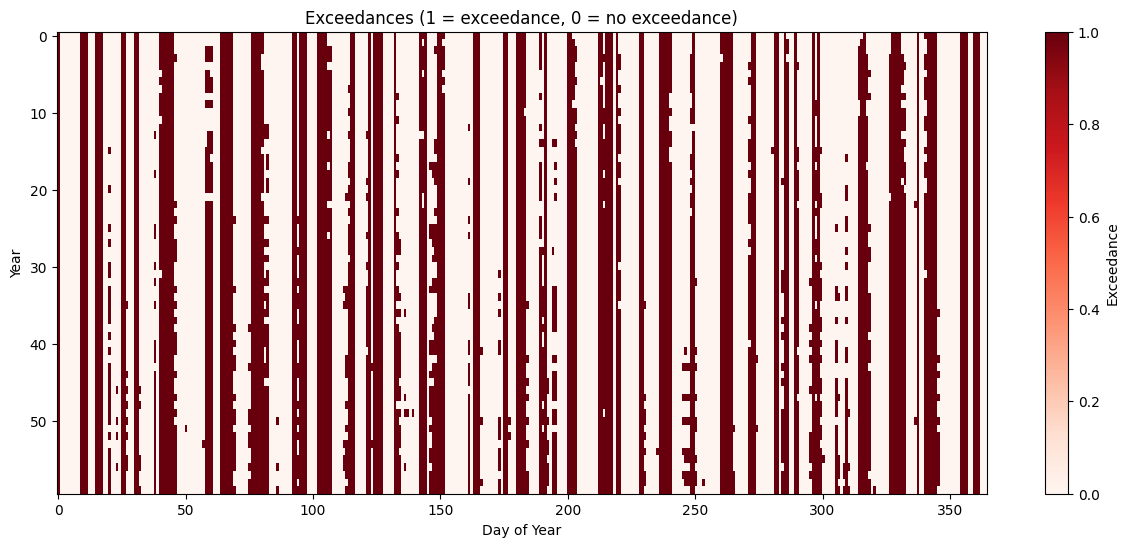

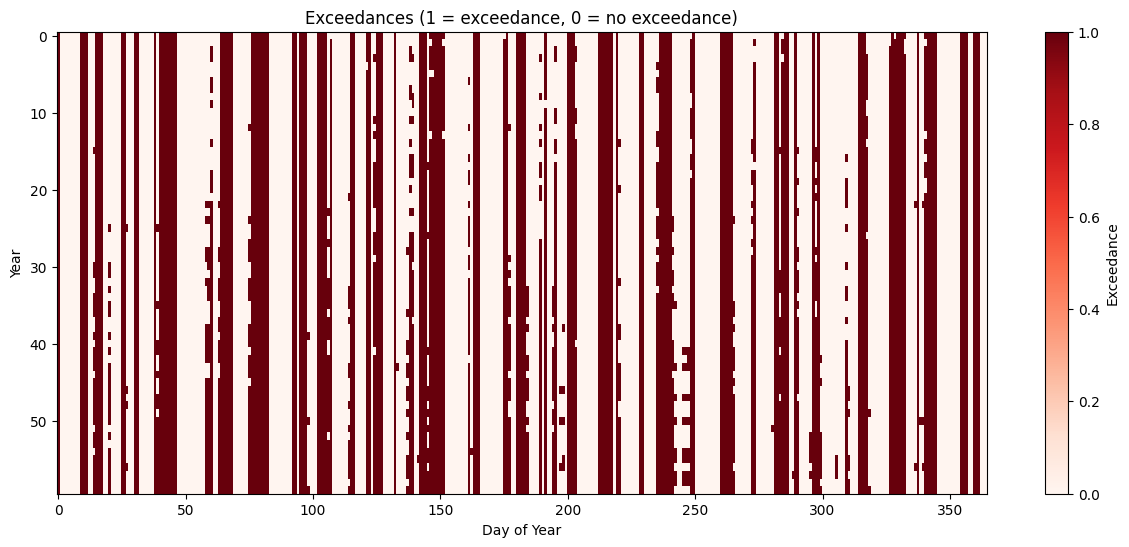

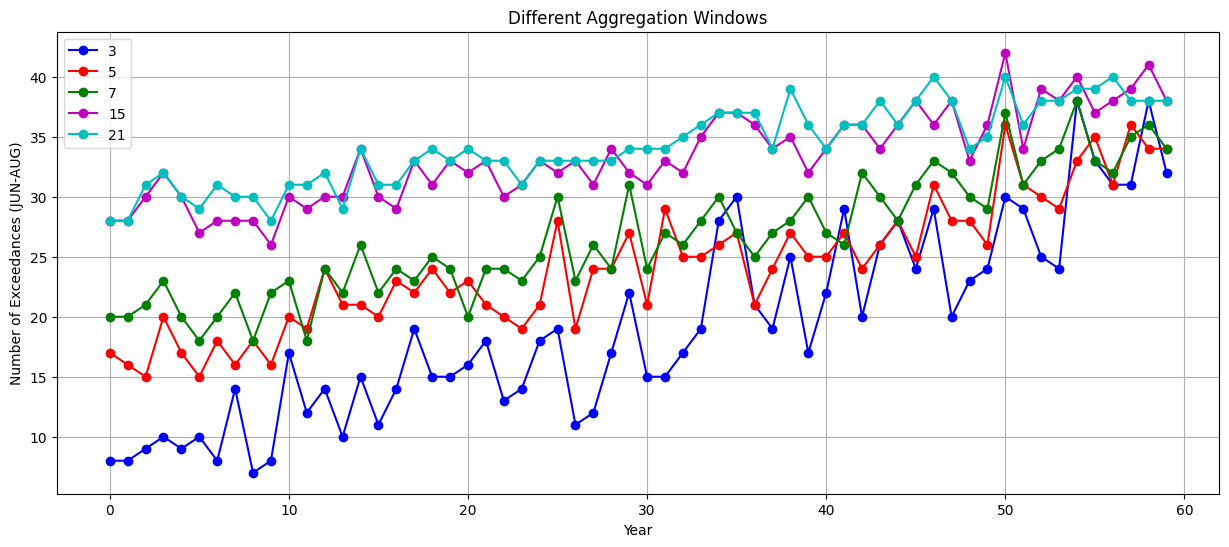

In [12]:
counts = []
for agg_window in [3,5,7,15,21]:
    agg = aggregate(trend_up, agg_window)
    exceedances = get_exceedances(agg, percentiles, perc_id=0)
    plot_exceedances(exceedances)
    summer_exceedances_count = count_ex_per_period(exceedances)
    counts.append( (summer_exceedances_count, agg_window) )
plot_count(counts, "Different Aggregation Windows")

# Simple Experiment 3:
# Test different boosting windows

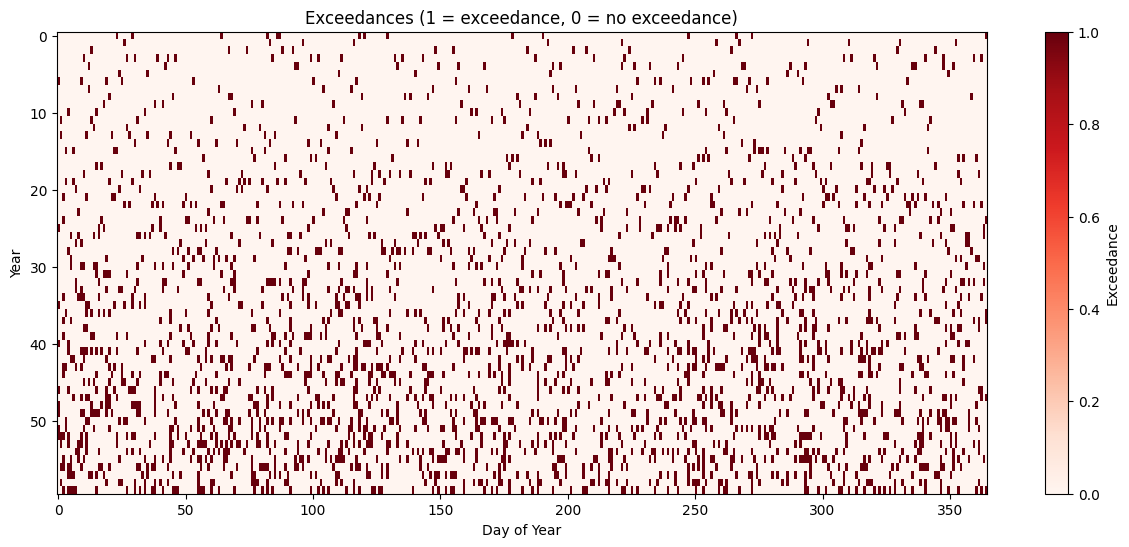

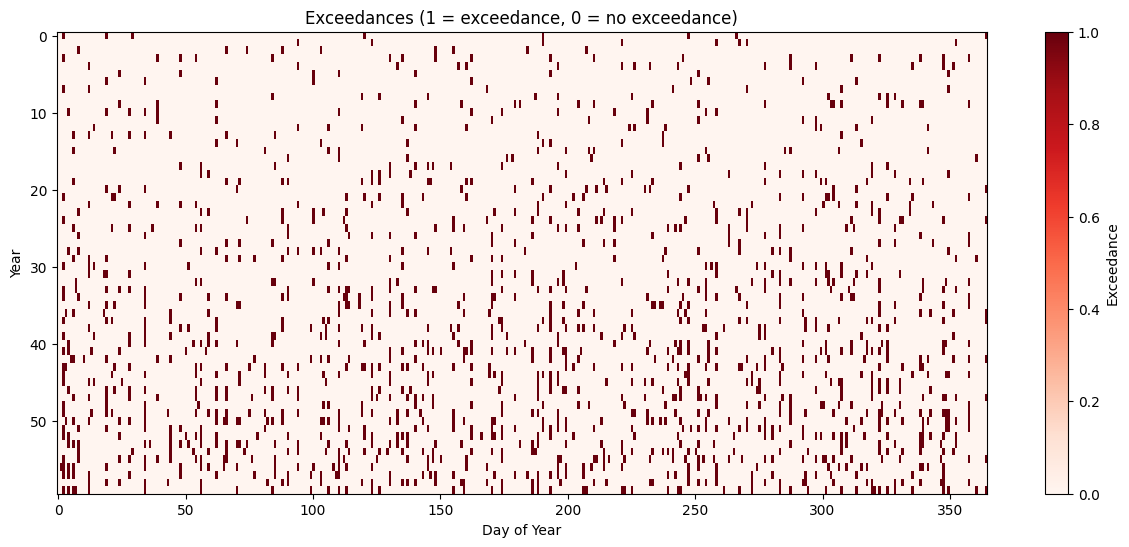

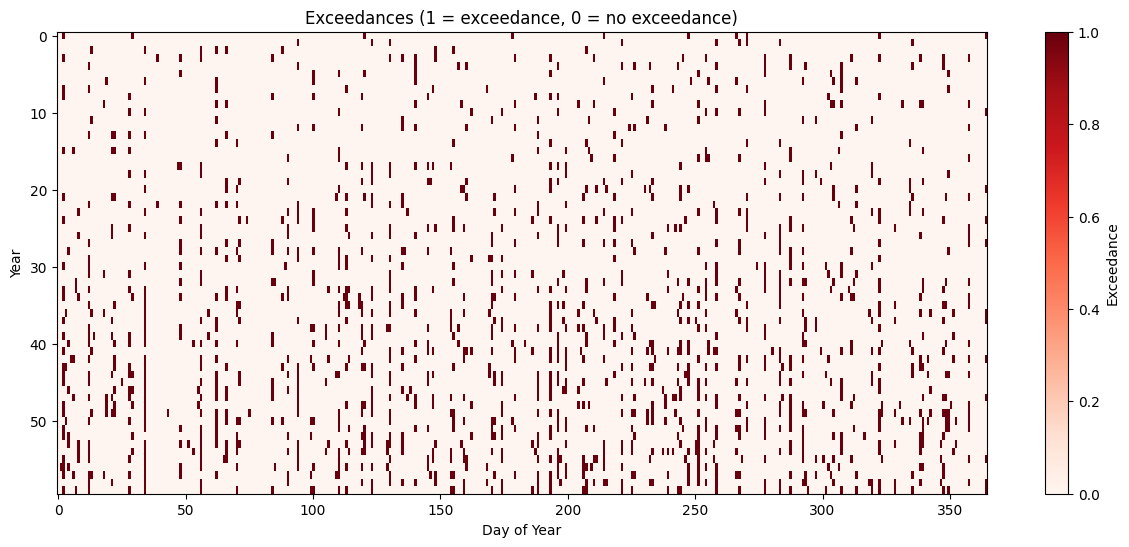

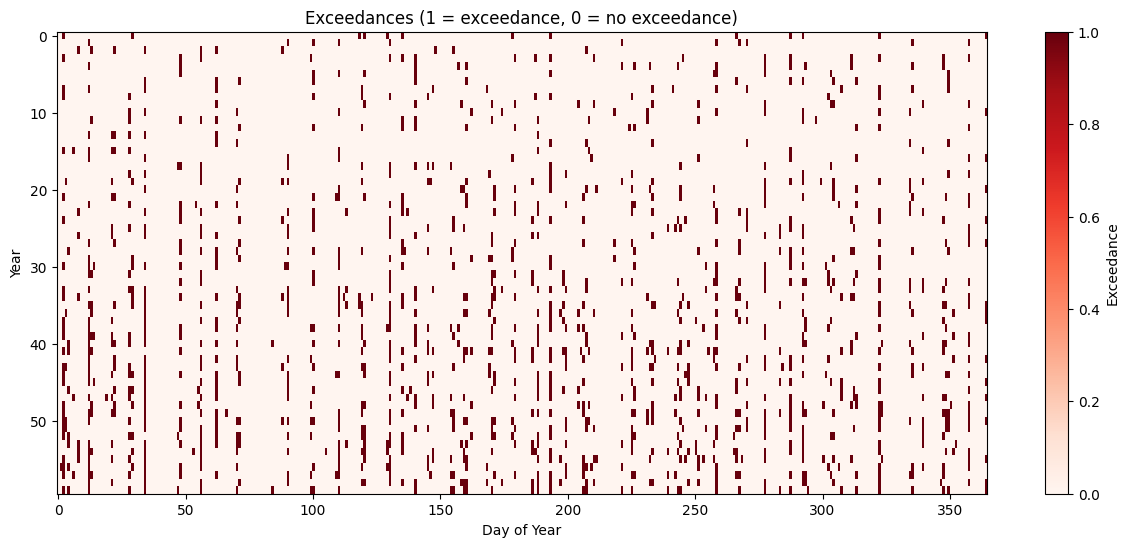

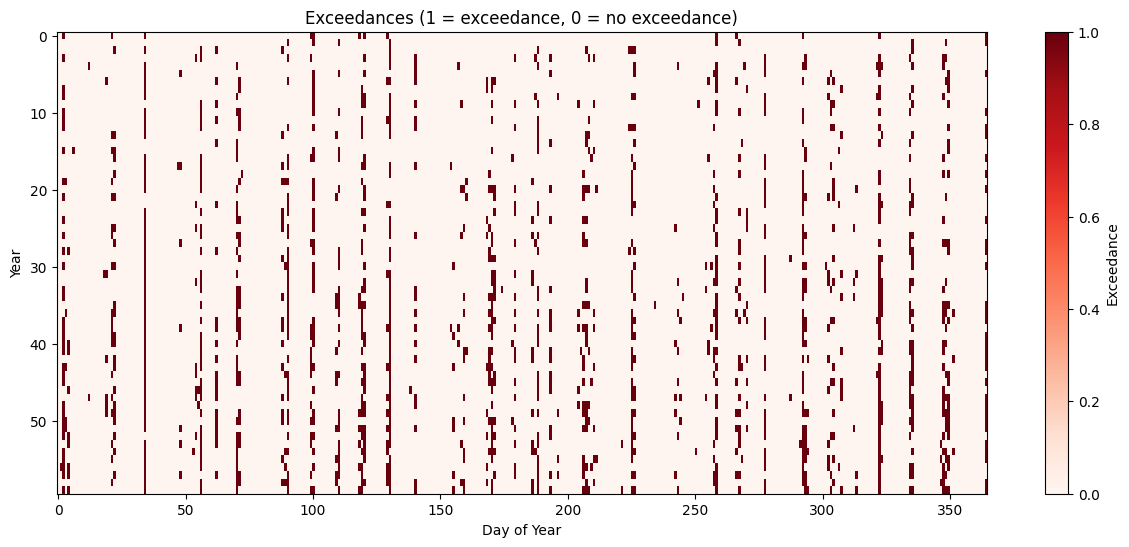

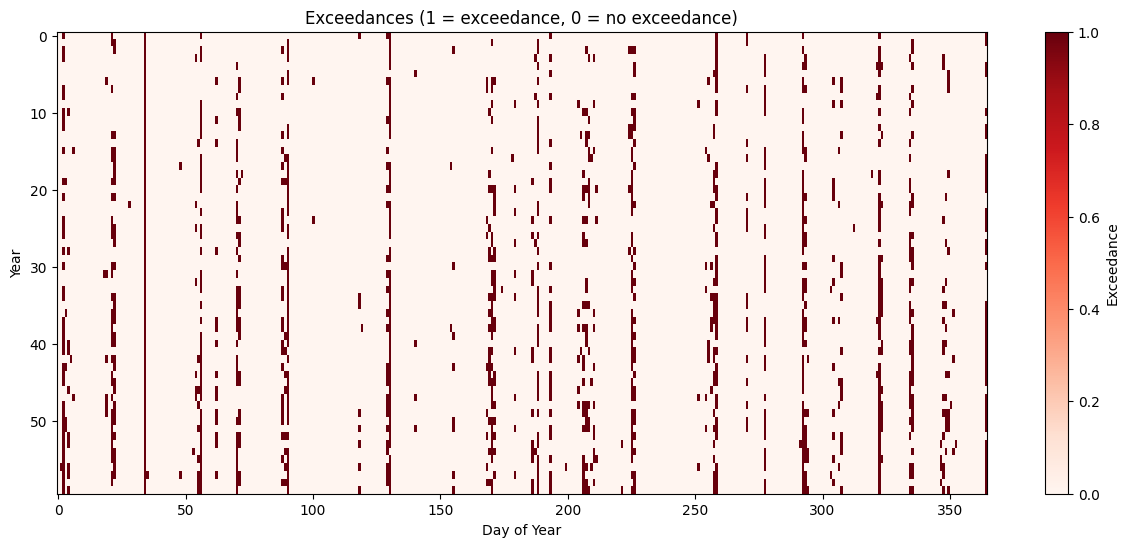

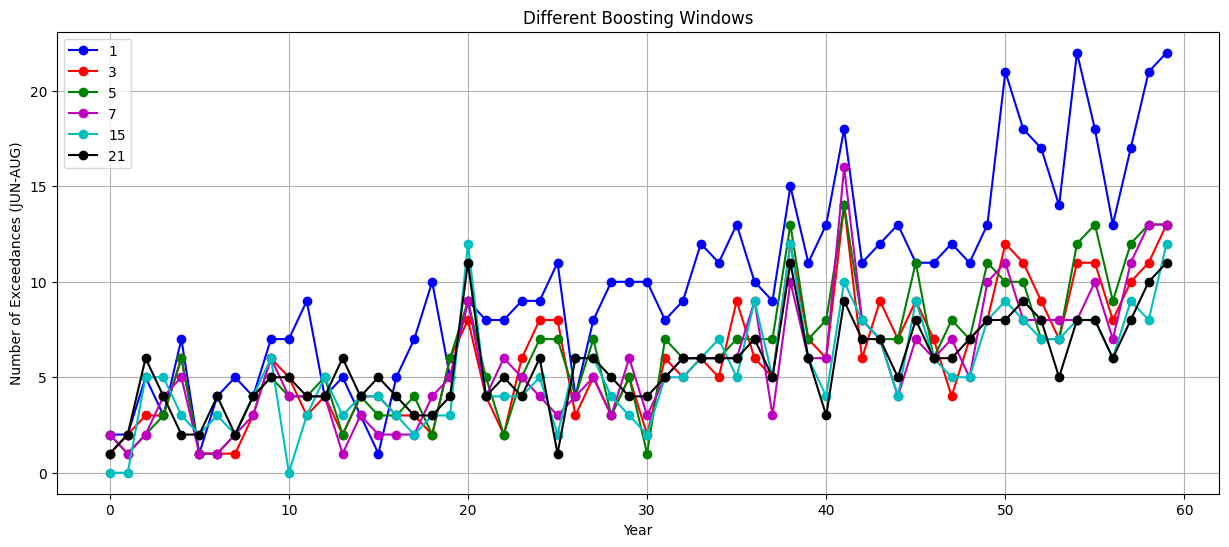

In [13]:
percs = [90, 95, 99]
perc = 95
perc_id = 1
doy = 30

counts = []
for boost in [1, 3, 5, 7, 15, 21]:
    percentiles = [[get_percentile_with_boosting(trend_up, perc, doy, boosting=boost) for perc in percs] for doy in range(365)]
    agg = get_exceedances(trend_up, percentiles, perc_id)
    plot_exceedances(agg)
    summer_exceedances_count = count_ex_per_period(agg)
    counts.append( (summer_exceedances_count, boost) )
plot_count(counts, "Different Boosting Windows")




# EXPERIMENT 4

See how counts exceedances of extremes are behaving when there is a downward trend

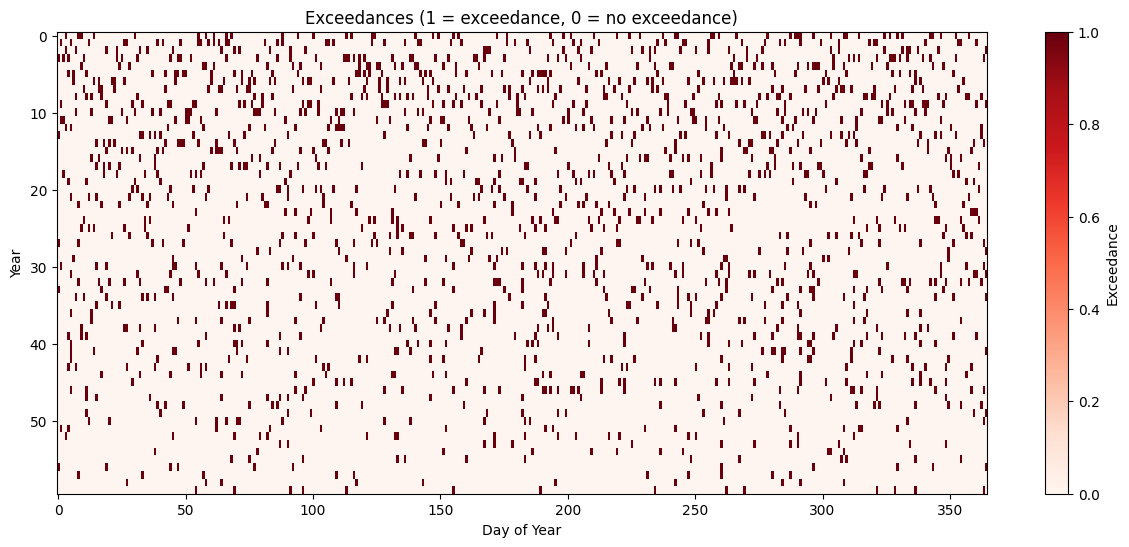

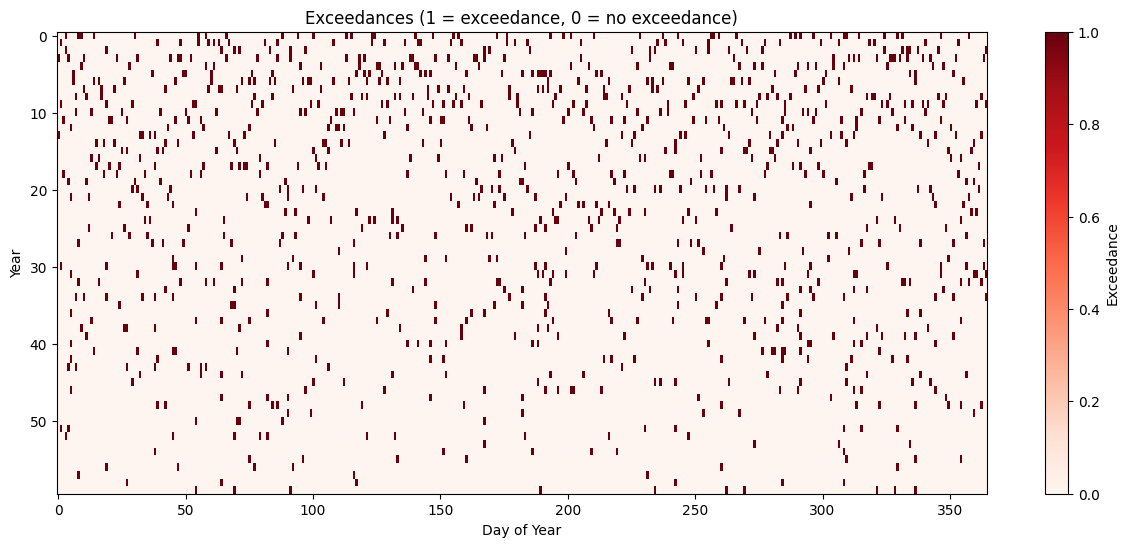

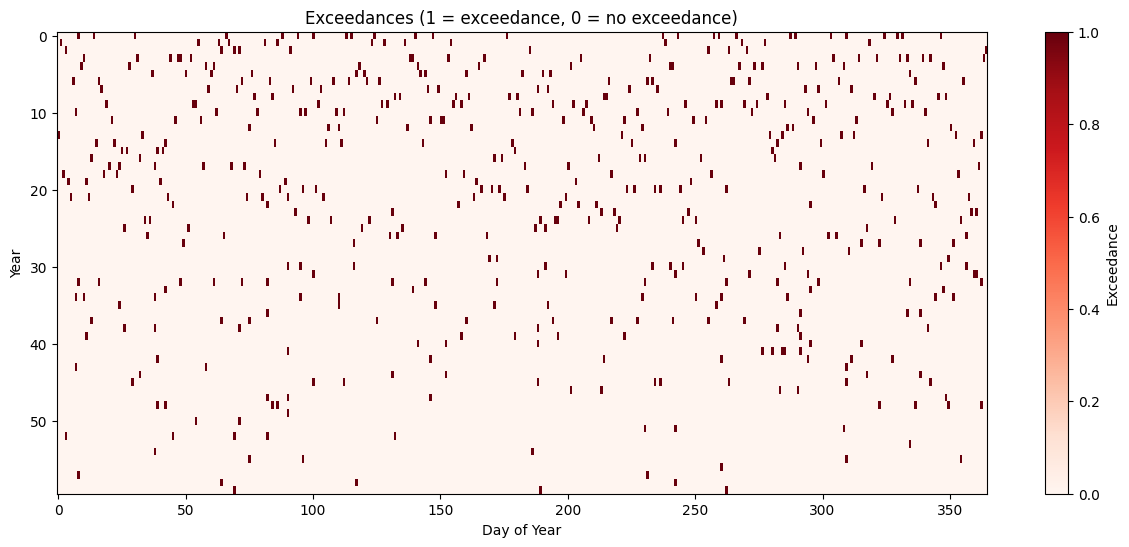

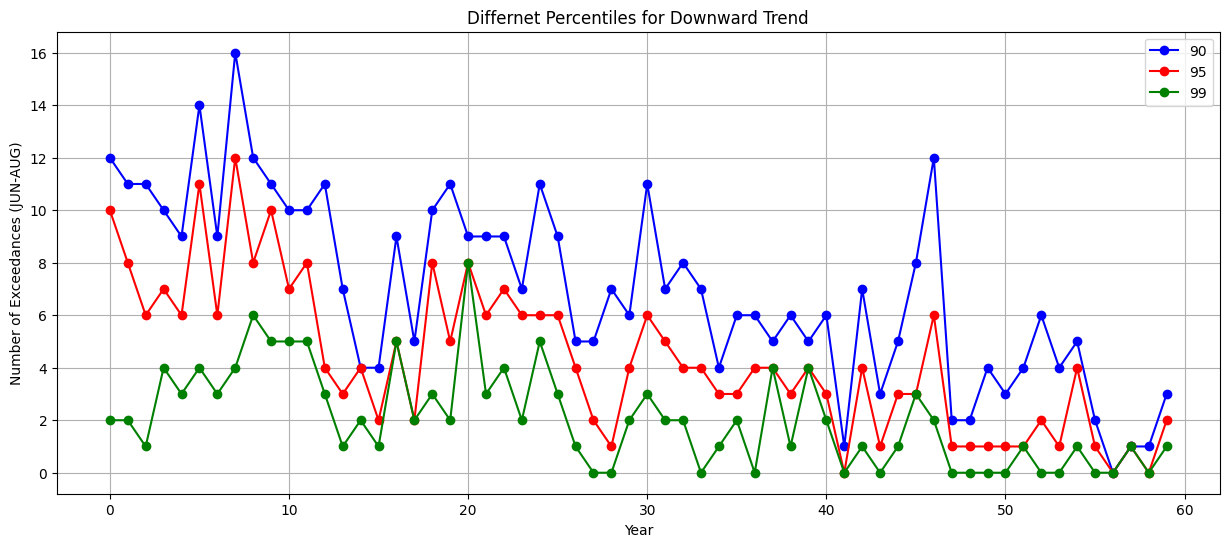

In [14]:
percs = [90, 95, 99]

doy = 30
percentiles = [[get_percentile(trend_down, perc, doy) for perc in percs] for doy in range(365)]

counts = []
for perc_id, perc in enumerate(percs):
    exceedances = get_exceedances(trend_down, percentiles, perc_id)
    plot_exceedances(exceedances)
    summer_exceedances_count = count_ex_per_period(exceedances)
    counts.append( (summer_exceedances_count, perc) )
plot_count(counts, "Differnet Percentiles for Downward Trend")





# EXPERIMENT 5, smaller trend

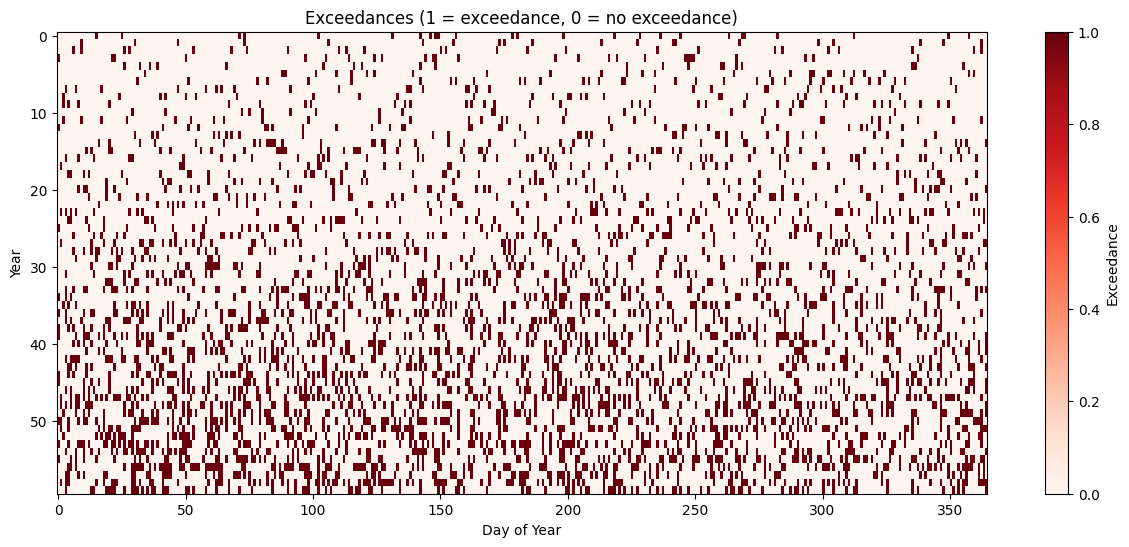

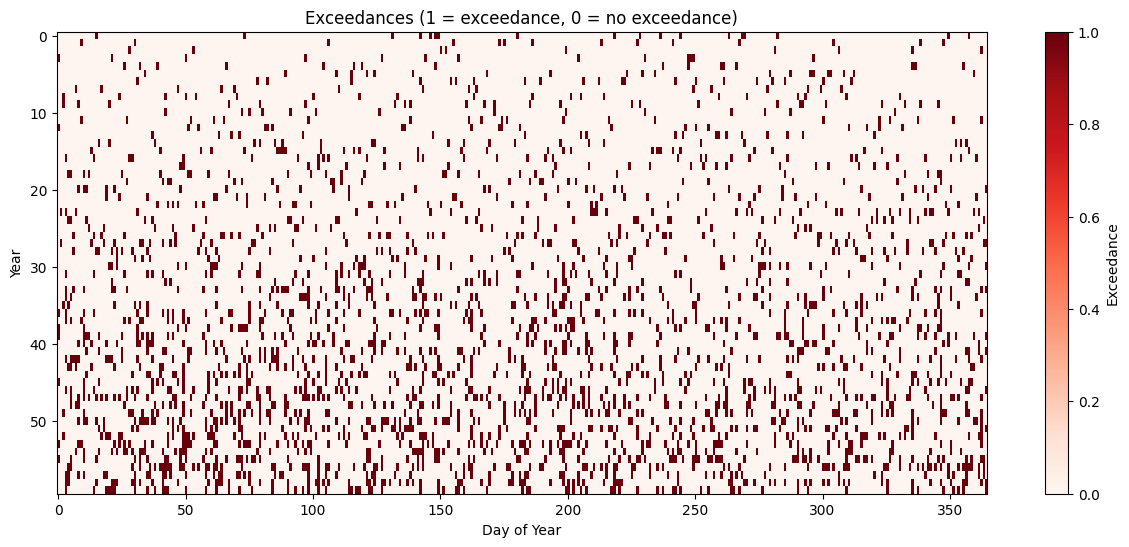

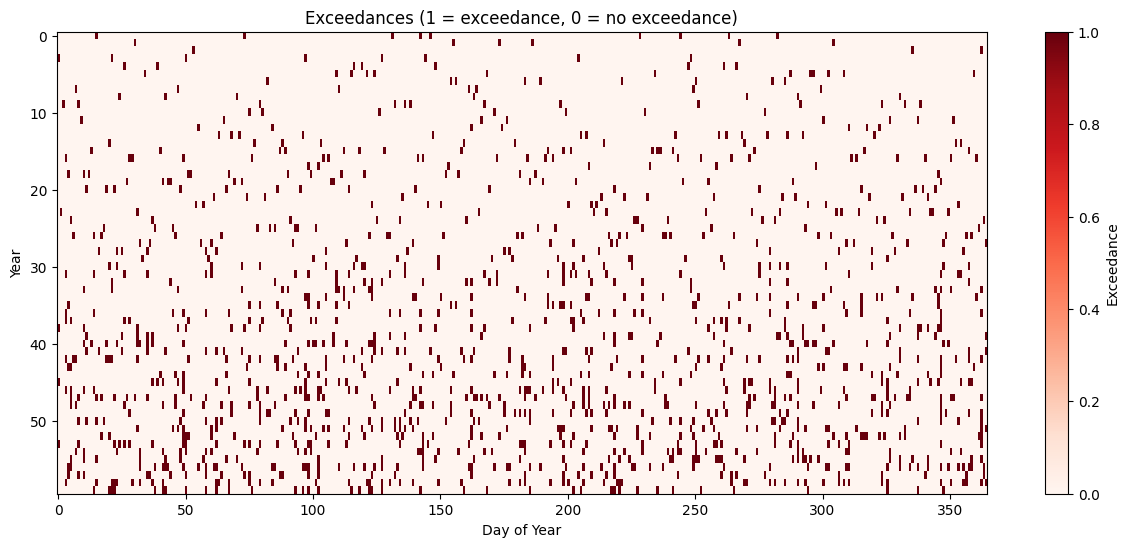

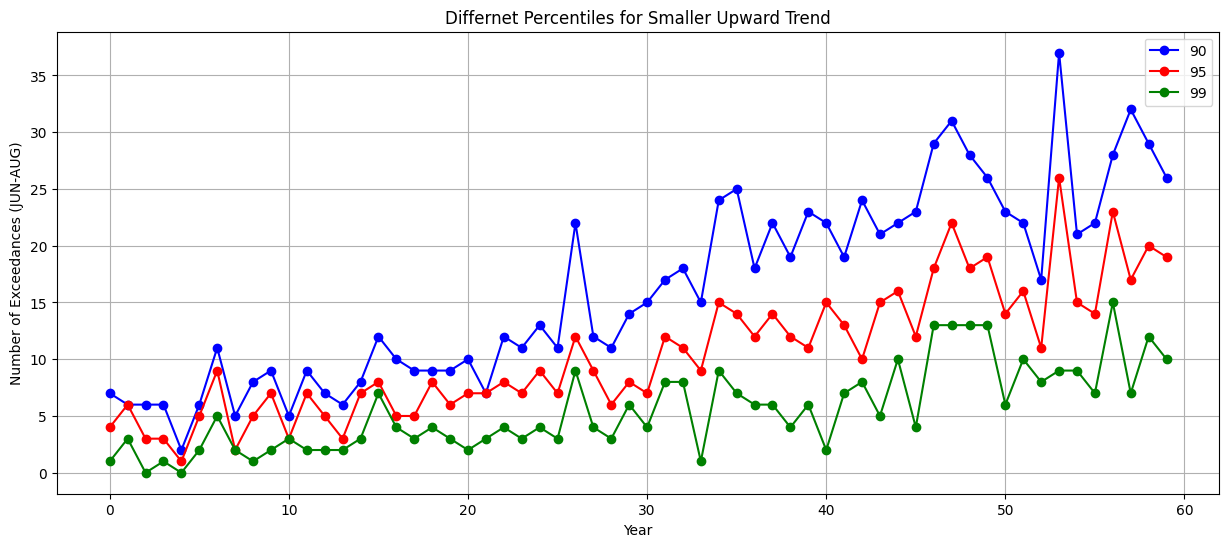

In [10]:
percs = [90, 95, 99]

doy = 30
percentiles = [[get_percentile(trend_up_smaller, perc, doy) for perc in percs] for doy in range(365)]

counts = []
for perc_id, perc in enumerate(percs):
    exceedances = get_exceedances(trend_up_smaller, percentiles, perc_id)
    plot_exceedances(exceedances)
    summer_exceedances_count = count_ex_per_period(exceedances)
    counts.append( (summer_exceedances_count, perc) )
plot_count(counts, "Differnet Percentiles for Smaller Upward Trend")




# EXPERIMENT 6, SMALLER TREND, DIFFERENT AGGREGATION WINDOWS

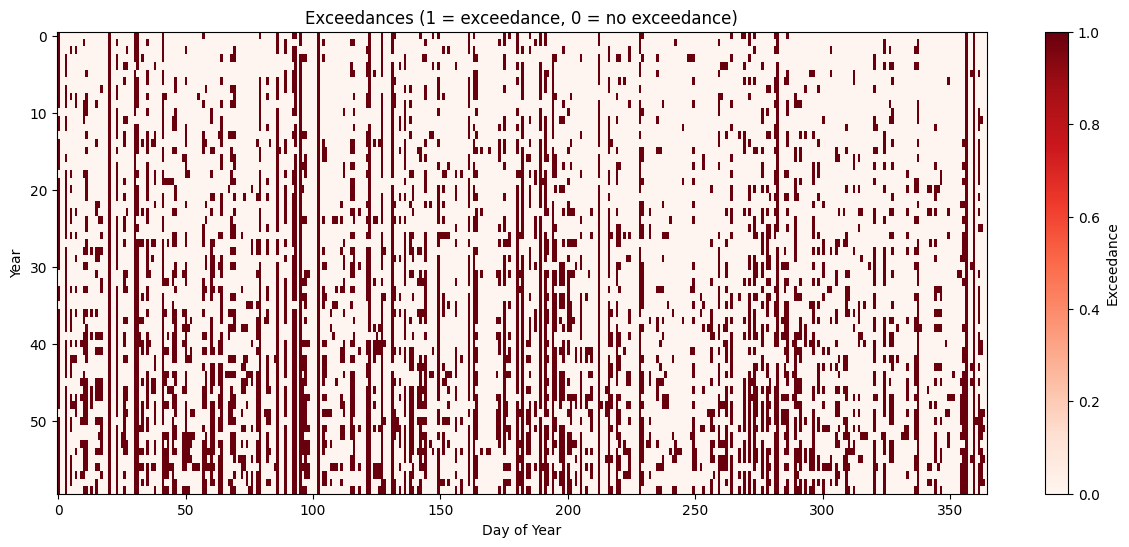

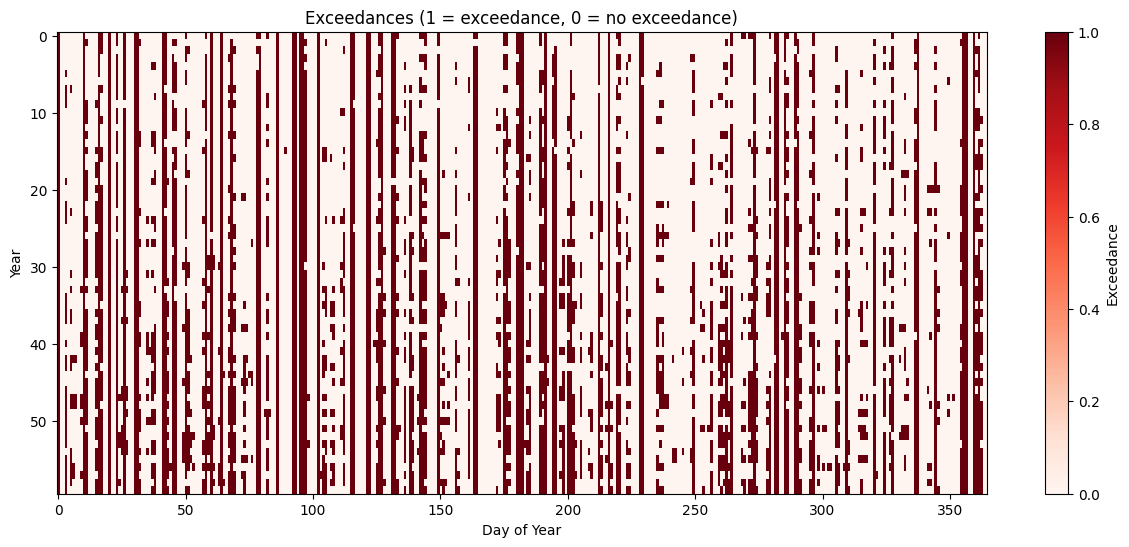

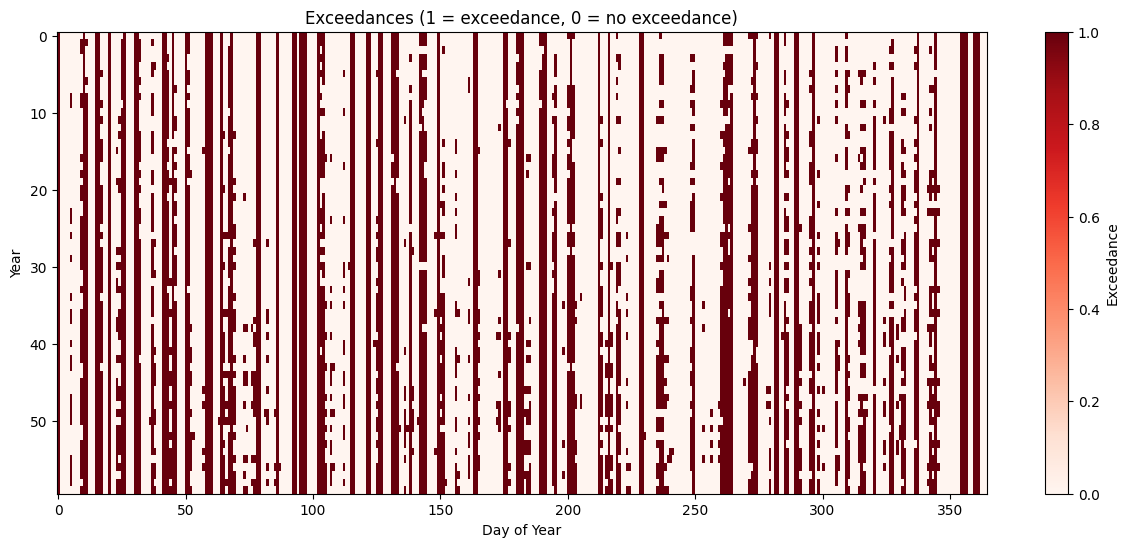

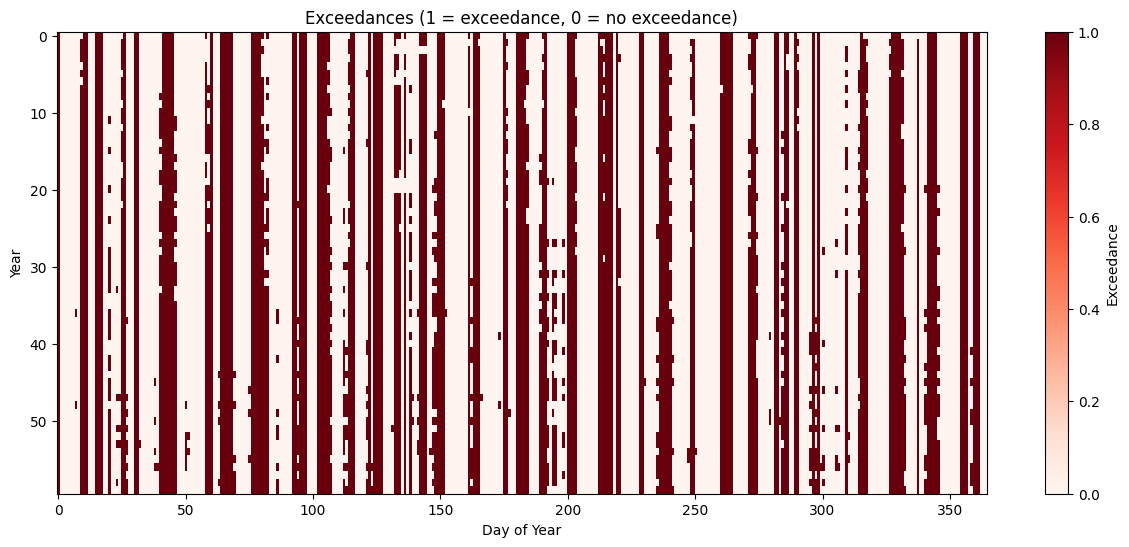

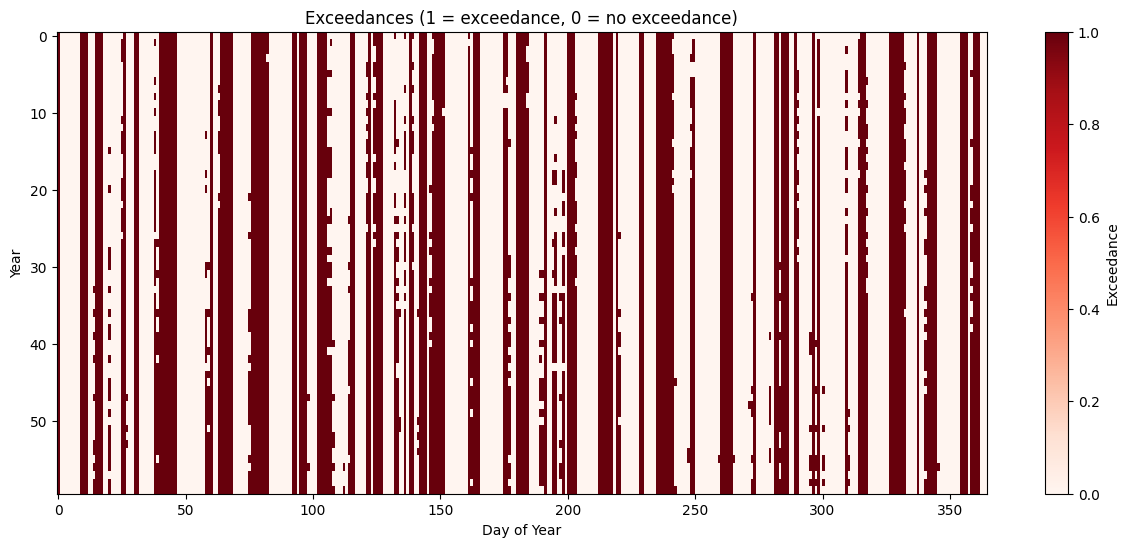

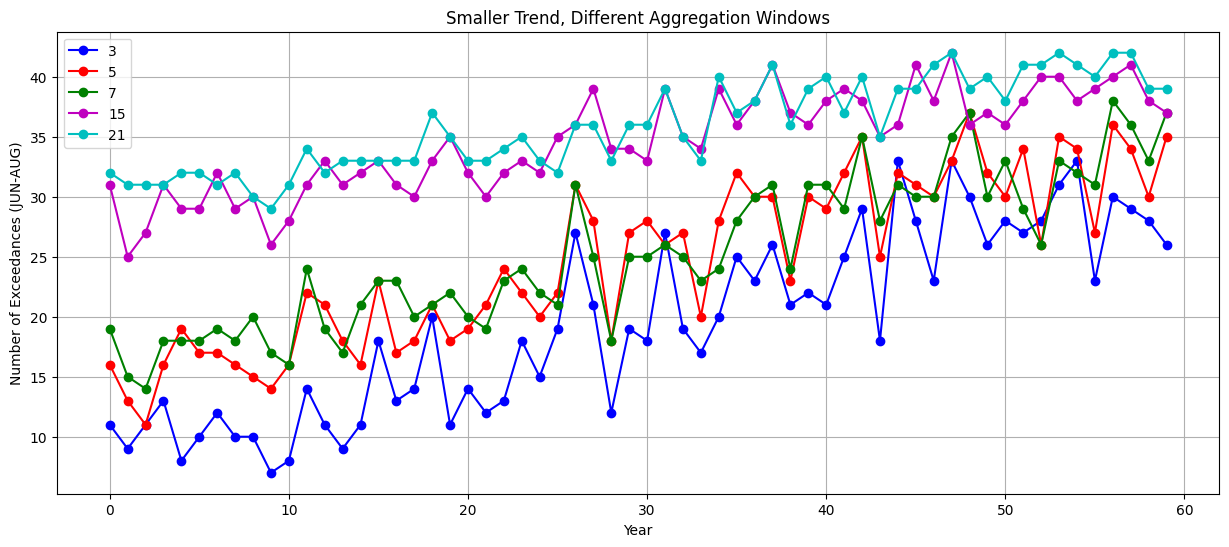

In [11]:
counts = []
for agg_window in [3,5,7,15,21]:
    agg = aggregate(trend_up_smaller, agg_window)
    exceedances = get_exceedances(agg, percentiles, perc_id=0)
    plot_exceedances(exceedances)
    summer_exceedances_count = count_ex_per_period(exceedances)
    counts.append( (summer_exceedances_count, agg_window) )
plot_count(counts, "Smaller Trend, Different Aggregation Windows")